In [31]:
# Imports
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [32]:
# Constants
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
LANG_COL_Q11 = "language_background_q.block_1/Q11"

TITLE_SUFFIX_NON_ENGLISH_L1 = " ESL"
TITLE_SUFFIX_ENGLISH_L1 = " English L1"

# Reading CSV files
def import_data():
    csv_paths = sorted(DATA_DIR.glob("*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

    frames = [pd.read_csv(path).assign(source_file=path.stem) for path in csv_paths]
    return pd.concat(frames, ignore_index=True)

    """
    I collected data from tasks that I am not analyzing yet.
    For this project, I am only analyzing data from the DF experiment and language background
    \questionnaire. Data from ART, LexTALE, and most of the language background questions (besides 
    2, 11, and 12) will be disregarded.
    """
def clean_data(df):
    clean_df = df.copy()
    clean_df.columns = [str(col).strip() for col in clean_df.columns]

    required_cols = ["ID", "R_F", "testing_input.keys"]
    missing = [col for col in required_cols if col not in clean_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    clean_df["ID"] = clean_df["ID"].astype(str).str.strip()
    clean_df["R_F"] = clean_df["R_F"].astype(str).str.strip().str.upper()
    clean_df["testing_input.keys"] = (
        clean_df["testing_input.keys"].astype(str).str.strip().str.lower()
    )

    # Normalizing common placeholders so downstream checks behave consistently
    clean_df["testing_input.keys"] = clean_df["testing_input.keys"].replace(
        {"": pd.NA, "nan": pd.NA, "none": pd.NA}
    )

    for col in ["word", "easy_hard"]:
        if col in clean_df.columns:
            clean_df[col] = clean_df[col].astype(str).str.strip()
            clean_df[col] = clean_df[col].replace({"": pd.NA, "nan": pd.NA, "none": pd.NA})

    if "source_file" not in clean_df.columns:
        clean_df["source_file"] = "unknown_source"

    return clean_df

# Normalizing difficulty
def _normalize_difficulty(series):
    diff_map = {
        "easy": "easy",
        "hard": "hard",
        "0": "easy",
        "1": "hard",
    }
    values = series.astype(str).str.strip().str.lower()
    normalized = values.map(diff_map)
    return normalized.where(normalized.isin(["easy", "hard"]))


def _difficulty_source_column(df):
    if "easy_hard" in df.columns:
        return "easy_hard"
    if "word" in df.columns:
        return "word"
    raise ValueError("Could not find a column containing easy/hard difficulty labels.")


def _std_or_zero(series):
    return float(series.std(ddof=1)) if len(series) > 1 else 0.0

# Creates stable stimulus keys within each source file
def _build_stimulus_key(df):
    out = df.copy()

    if "word" in out.columns:
        word = out["word"].astype(str).str.strip().str.upper()
        has_word = word.ne("") & ~word.eq("NAN")
    else:
        word = pd.Series("", index=out.index)
        has_word = pd.Series(False, index=out.index)

    fallback = out["ID"].astype(str).str.strip()
    stim = word.where(has_word, fallback)
    out["stimulus_key"] = out["source_file"].astype(str).str.strip() + "||" + stim
    return out

# Infer old/new key mapping independently per source file
def _infer_old_key_by_file(response_df):

    def _best_old_key(group):
        key = group["testing_input.keys"]
        is_old = group["is_old"]

        agree_a = ((is_old & key.eq("z")) | (~is_old & key.eq("m"))).mean()
        agree_b = ((is_old & key.eq("m")) | (~is_old & key.eq("z"))).mean()
        return "z" if agree_a >= agree_b else "m"

    return response_df.groupby("source_file").apply(_best_old_key).to_dict()


"""
Scores responses with participant-specific key mapping.
Scoring rules:
- Old item (mapped R or F): z is correct
- New item (no R/F mapping): m is correct
"""
def calculate_correctness(df):
    scored_df = _build_stimulus_key(df)

    # Identifying new/old items
    rf_lookup = (
        scored_df[scored_df["R_F"].isin(["R", "F"])]
        .groupby("stimulus_key")["R_F"]
        .first()
        .to_dict()
    )

    # Storing each word into a dataframe
    response_df = scored_df[scored_df["testing_input.keys"].isin(["z", "m"])].copy()
    response_df["mapped_R_F"] = response_df["stimulus_key"].map(rf_lookup)
    response_df["is_old"] = response_df["mapped_R_F"].isin(["R", "F"])

    old_key_by_file = _infer_old_key_by_file(response_df)
    response_df["old_key"] = response_df["source_file"].map(old_key_by_file)
    response_df["new_key"] = response_df["old_key"].map({"z": "m", "m": "z"})

    # Keep all old-item responses; keep only correct rejections for new items
    keep_mask = response_df["is_old"] | (
        ~response_df["is_old"]
        & response_df["testing_input.keys"].eq(response_df["new_key"])
    )
    response_df = response_df[keep_mask].copy()

    response_df["correct"] = (
        (response_df["is_old"] & response_df["testing_input.keys"].eq(response_df["old_key"]))
        | (~response_df["is_old"] & response_df["testing_input.keys"].eq(response_df["new_key"]))
    )

    return response_df

# Calculating accuracy by difficulty
def _get_easy_hard_r_f_accuracy_by_file(scored_df):
    """Return per-file accuracy series for easy_r, easy_f, hard_r, hard_f."""
    work_df = scored_df.copy()
    source_col = _difficulty_source_column(work_df)
    work_df["difficulty"] = _normalize_difficulty(work_df[source_col])

    old_items = work_df[work_df["mapped_R_F"].isin(["R", "F"])].copy()

    accuracy_by_file = (
        old_items.dropna(subset=["difficulty"])
        .groupby(["source_file", "difficulty", "mapped_R_F"]) ["correct"]
        .mean()
    )

    def _extract_bucket(difficulty, rf_type):
        mask = (accuracy_by_file.index.get_level_values("difficulty") == difficulty) & (
            accuracy_by_file.index.get_level_values("mapped_R_F") == rf_type
        )
        result = accuracy_by_file[mask]
        if len(result) == 0:
            return pd.Series(dtype=float)
        return result.droplevel(["difficulty", "mapped_R_F"])

    easy_r = _extract_bucket("easy", "R")
    easy_f = _extract_bucket("easy", "F")
    hard_r = _extract_bucket("hard", "R")
    hard_f = _extract_bucket("hard", "F")

    return easy_r, easy_f, hard_r, hard_f

# Generating box plots
def _plot_easy_hard_bars(ax, easy_accuracy, hard_accuracy, title):
    if easy_accuracy.empty or hard_accuracy.empty:
        raise ValueError(f"Not enough easy/hard data to create both bars for {title}.")

    means = [easy_accuracy.mean(), hard_accuracy.mean()]
    errors = [_std_or_zero(easy_accuracy), _std_or_zero(hard_accuracy)]
    x_pos = [0, 1]

    ax.bar(x_pos, means, color=["#5BA6FF", "#FF8A5B"], edgecolor="black", width=0.5)
    ax.errorbar(
        x_pos,
        means,
        yerr=errors,
        fmt="none",
        ecolor="black",
        capsize=30,
        capthick=1.5,
        elinewidth=1.5,
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(["Easy", "Hard"])
    ax.set_title(title)
    ax.set_ylabel("Accuracy Rate")
    ax.set_ylim(0, 1)

# Generating box plots by difficulty
def _plot_old_new_by_difficulty(ax, easy_r, easy_f, hard_r, hard_f, title):
    """Plot R and F accuracy for easy and hard words as grouped bars."""
    easy_r_mean = easy_r.mean() if len(easy_r) > 0 else 0.0
    easy_f_mean = easy_f.mean() if len(easy_f) > 0 else 0.0
    hard_r_mean = hard_r.mean() if len(hard_r) > 0 else 0.0
    hard_f_mean = hard_f.mean() if len(hard_f) > 0 else 0.0

    easy_r_err = _std_or_zero(easy_r)
    easy_f_err = _std_or_zero(easy_f)
    hard_r_err = _std_or_zero(hard_r)
    hard_f_err = _std_or_zero(hard_f)

    x_pos = [0, 1]
    width = 0.35

    r_x = [x - width / 2 for x in x_pos]
    f_x = [x + width / 2 for x in x_pos]

    means_r = [easy_r_mean, hard_r_mean]
    means_f = [easy_f_mean, hard_f_mean]
    err_r = [easy_r_err, hard_r_err]
    err_f = [easy_f_err, hard_f_err]

    ax.bar(r_x, means_r, color="#5BA6FF", edgecolor="black", width=width, label="R-items")
    ax.bar(f_x, means_f, color="#FF8A5B", edgecolor="black", width=width, label="F-items")

    ax.errorbar(r_x, means_r, yerr=err_r, fmt="none", ecolor="black", capsize=4, elinewidth=1)
    ax.errorbar(f_x, means_f, yerr=err_f, fmt="none", ecolor="black", capsize=4, elinewidth=1)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(["Easy Words", "Difficult Words"])
    ax.set_ylabel("Percentage of correctly recalled items")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False)


def _print_bucket_statistics(easy_r, easy_f, hard_r, hard_f, title_suffix=""):
    print(f"\nBucket statistics (old items only){title_suffix}:")
    buckets = [
        ("Easy R", easy_r),
        ("Easy F", easy_f),
        ("Hard R", hard_r),
        ("Hard F", hard_f),
    ]

    for label, values in buckets:
        mean_val = float(values.mean()) if len(values) > 0 else float("nan")
        std_val = float(values.std(ddof=1)) if len(values) > 1 else 0.0
        print(f"  {label}: mean={mean_val:.6f}, std={std_val:.6f}, n_files={len(values)}")


def _filter_esl_participants(df):
    """Keep source files where Q11 is present and not 'other'/'none'."""
    if LANG_COL_Q11 not in df.columns:
        return None

    q11_values = df[LANG_COL_Q11].astype(str).str.strip().str.lower()
    is_excluded = (
        q11_values.str.contains("other", na=False)
        | q11_values.str.contains("none", na=False)
        | df[LANG_COL_Q11].isna()
    )
    q11_valid = ~is_excluded

    file_flags = (
        pd.DataFrame({"source_file": df["source_file"], "q11_valid": q11_valid})
        .groupby("source_file", as_index=False)
        .agg(has_valid_q11=("q11_valid", "any"))
    )

    selected = file_flags[file_flags["has_valid_q11"]]
    if selected.empty:
        return None

    return df[df["source_file"].isin(selected["source_file"])].copy()


def _filter_other_language_participants(df):
    """
    Keep files with Q11='other' or all Q11 missing, or missing Q11 column.
    """
    if LANG_COL_Q11 not in df.columns:
        return df.copy()

    file_flags = (
        pd.DataFrame(
            {
                "source_file": df["source_file"],
                "q11_is_other": df[LANG_COL_Q11].astype(str).str.contains(
                    "other", case=False, na=False
                ),
                "q11_is_nan": df[LANG_COL_Q11].isna(),
            }
        )
        .groupby("source_file", as_index=False)
        .agg(
            q11_is_other=("q11_is_other", "any"),
            q11_all_nan=("q11_is_nan", "all"),
        )
    )

    selected = file_flags[file_flags["q11_is_other"] | file_flags["q11_all_nan"]]
    if selected.empty:
        return None

    return df[df["source_file"].isin(selected["source_file"])].copy()


def create_r_and_f_words_correctness_boxplots(clean_df, title_suffix=""):
    scored_df = calculate_correctness(clean_df)
    scored_df["correct"] = scored_df["correct"].astype(int)

    easy_r, easy_f, hard_r, hard_f = _get_easy_hard_r_f_accuracy_by_file(scored_df)

    if easy_r.empty or easy_f.empty or hard_r.empty or hard_f.empty:
        raise ValueError(
            "Not enough data to compute all four groups: easy-R, easy-F, hard-R, hard-F."
        )

    _print_bucket_statistics(easy_r, easy_f, hard_r, hard_f, title_suffix=title_suffix)

    fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.0))
    _plot_old_new_by_difficulty(
        ax,
        easy_r,
        easy_f,
        hard_r,
        hard_f,
        f"DF Performance{title_suffix}",
    )

    plt.tight_layout()
    plt.show()
    return fig


def create_false_alarm_figure(clean_df, title_suffix=""):
    """
    False alarm = response on a new item that matches the inferred old key.
    """
    work_df = _build_stimulus_key(clean_df)
    stimulus_col = _difficulty_source_column(work_df)

    rf_lookup = (
        work_df[work_df["R_F"].isin(["R", "F"])]
        .groupby("stimulus_key")["R_F"]
        .first()
        .to_dict()
    )

    response_df = work_df[work_df["testing_input.keys"].isin(["z", "m"])].copy()
    response_df["mapped_R_F"] = response_df["stimulus_key"].map(rf_lookup)
    response_df["is_old"] = response_df["mapped_R_F"].isin(["R", "F"])

    old_key_by_file = _infer_old_key_by_file(response_df)
    response_df["old_key"] = response_df["source_file"].map(old_key_by_file)

    response_df["difficulty"] = _normalize_difficulty(response_df[stimulus_col])
    new_items = response_df[(~response_df["is_old"]) & response_df["difficulty"].notna()].copy()

    if new_items.empty:
        print(f"No new-item response rows available for false-alarm analysis{title_suffix}.")
        return None

    new_items["false_alarm"] = new_items["testing_input.keys"].eq(new_items["old_key"]).astype(int)

    rates = (
        new_items.groupby(["source_file", "difficulty"])["false_alarm"]
        .mean()
        .unstack("difficulty")
    )

    easy_rate = (rates["easy"] if "easy" in rates else pd.Series(dtype=float)).dropna()
    hard_rate = (rates["hard"] if "hard" in rates else pd.Series(dtype=float)).dropna()

    if easy_rate.empty or hard_rate.empty:
        print(f"Not enough easy/hard new-item data to plot false alarms{title_suffix}.")
        return None

    print(f"\nFalse alarm statistics{title_suffix}:")
    print(
        f"  Easy new words: mean={easy_rate.mean():.6f}, std={_std_or_zero(easy_rate):.6f}, n_files={len(easy_rate)}"
    )
    print(
        f"  Hard new words: mean={hard_rate.mean():.6f}, std={_std_or_zero(hard_rate):.6f}, n_files={len(hard_rate)}"
    )

    fig, ax = plt.subplots(1, 1, figsize=(6.8, 5.0))
    _plot_easy_hard_bars(
        ax,
        easy_rate,
        hard_rate,
        f"False Alarm Rate (New Items){title_suffix}",
    )
    ax.set_ylabel("False Alarm Rate")
    plt.tight_layout()
    plt.show()

    return fig


def main():
    df = import_data()
    clean_df = clean_data(df)

    # Figures 1 & 2: participants whose Q11 is not "other" or "none"; ESL participants
    esl_df = _filter_esl_participants(clean_df)
    if esl_df is not None:
        n = esl_df["source_file"].nunique()
        print(f"\nGenerating figures for {n} participant(s) with a specific Q11 answer.")
        create_r_and_f_words_correctness_boxplots(esl_df, title_suffix=TITLE_SUFFIX_NON_ENGLISH_L1)
    else:
        print("\nNo participants found with a Q11 answer other than 'other'/'none' - skipping figures 1 & 2.")

    # Figures 3 & 4: participants with no Q11 in CSV or Q11 contains "other"; English L1 participants
    other_df = _filter_other_language_participants(clean_df)
    if other_df is not None:
        n = other_df["source_file"].nunique()
        print(f"\nGenerating 'Other/No Q11' language figures for {n} participant(s).")
        create_r_and_f_words_correctness_boxplots(
            other_df,
            title_suffix=TITLE_SUFFIX_ENGLISH_L1,
        )
    else:
        print(
            "\nNo participants matched (Q11 contains 'other' or Q11 absent) - skipping other language figures."
        )

    print("Analysis complete.")
    print(f"Rows loaded: {len(df)}")
    print(f"Rows after cleaning: {len(clean_df)}")

<>:21: SyntaxWarning: invalid escape sequence '\q'
<>:21: SyntaxWarning: invalid escape sequence '\q'
/var/folders/_w/s3nfswsj6873t8jl018_zb1w0000gn/T/ipykernel_82774/751088824.py:21: SyntaxWarning: invalid escape sequence '\q'
  \questionnaire. Data from ART, LexTALE, and most of the language background questions (besides



Generating figures for 2 participant(s) with a specific Q11 answer.

Bucket statistics (old items only) ESL:
  Easy R: mean=0.846154, std=0.108786, n_files=2
  Easy F: mean=0.727273, std=0.128565, n_files=2
  Hard R: mean=0.708333, std=0.058926, n_files=2
  Hard F: mean=0.666667, std=0.117851, n_files=2


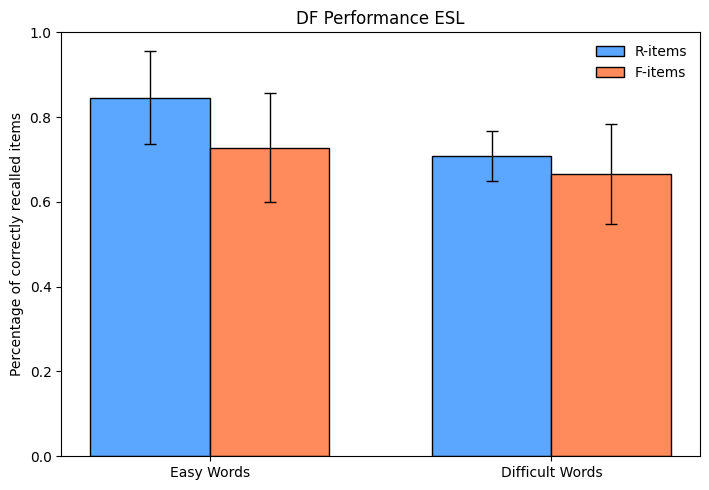


Generating 'Other/No Q11' language figures for 14 participant(s).

Bucket statistics (old items only) English L1:
  Easy R: mean=0.762363, std=0.167904, n_files=14
  Easy F: mean=0.517857, std=0.186909, n_files=14
  Hard R: mean=0.847527, std=0.186960, n_files=14
  Hard F: mean=0.728355, std=0.202797, n_files=14


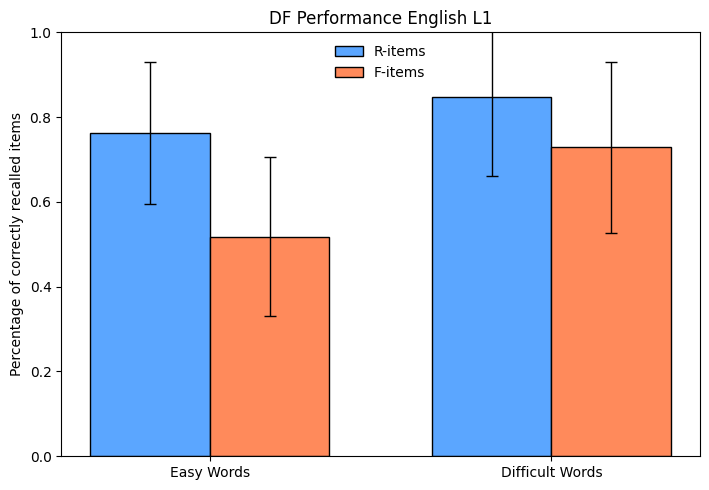

Analysis complete.
Rows loaded: 5052
Rows after cleaning: 5052


In [33]:
# Run this cell to display R and F/no-label Easy vs Hard boxplots
main()


False alarm statistics - ESL:
  Easy new words: mean=0.062500, std=0.088388, n_files=2
  Hard new words: mean=0.229167, std=0.029463, n_files=2


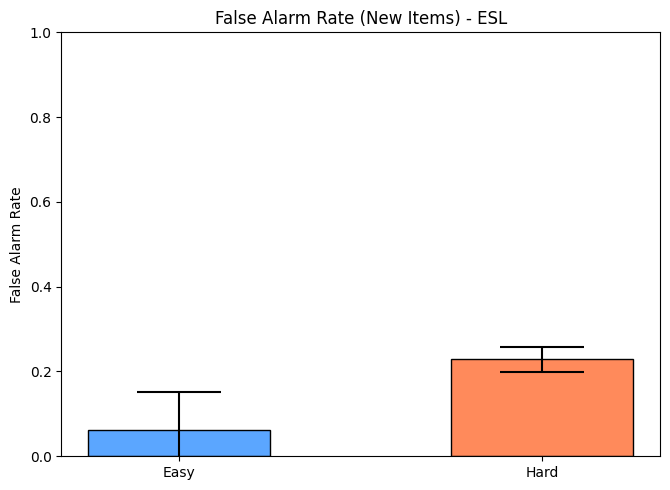


False alarm statistics - English L1:
  Easy new words: mean=0.169643, std=0.180118, n_files=14
  Hard new words: mean=0.238095, std=0.154550, n_files=14


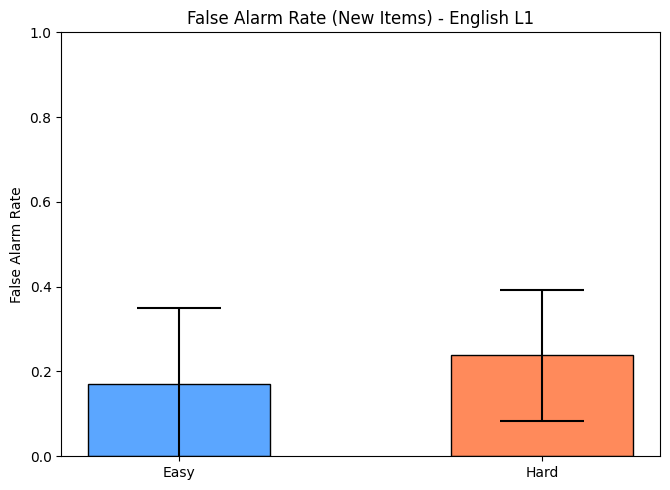

In [34]:
# False alarm analysis (new items incorrectly judged as old)
# Uses create_false_alarm_figure from the corrected scoring cell

fa_df = import_data()
fa_clean_df = clean_data(fa_df)

fa_esl_df = _filter_esl_participants(fa_clean_df)
if fa_esl_df is not None:
    create_false_alarm_figure(fa_esl_df, title_suffix=" - ESL")
else:
    print("No ESL subset for false alarm figure.")

fa_other_df = _filter_other_language_participants(fa_clean_df)
if fa_other_df is not None:
    create_false_alarm_figure(fa_other_df, title_suffix=" - English L1")
else:
    print("No English L1 subset for false alarm figure.")

In [35]:
# Optional cleanup: clear transient variables from the notebook namespace
# Run after analysis cells if you want a cleaner variable list

_keep_names = {
    # Core modules/objects
    "pd", "plt", "Path",
    # Config constants
    "PROJECT_DIR", "DATA_DIR", "LANG_COL_Q11",
    "TITLE_SUFFIX_ENGLISH_L1", "TITLE_SUFFIX_NON_ENGLISH_L1",
    # Reusable functions
    "import_data", "clean_data", "_normalize_difficulty", "_difficulty_source_column",
    "_std_or_zero", "_build_stimulus_key", "_infer_old_key_by_file", "calculate_correctness",
    "_get_easy_hard_r_f_accuracy_by_file", "_plot_easy_hard_bars", "_plot_old_new_by_difficulty",
    "_print_bucket_statistics", "_filter_esl_participants", "_filter_other_language_participants",
    "create_r_and_f_words_correctness_boxplots", "create_false_alarm_figure", "main",
}

for _name in list(globals().keys()):
    if _name.startswith("_"):
        continue
    if _name in _keep_names:
        continue
    if _name in {"In", "Out", "get_ipython", "exit", "quit"}:
        continue
    del globals()[_name]

print("Cleanup complete: transient variables removed; analysis functions retained.")

Cleanup complete: transient variables removed; analysis functions retained.
